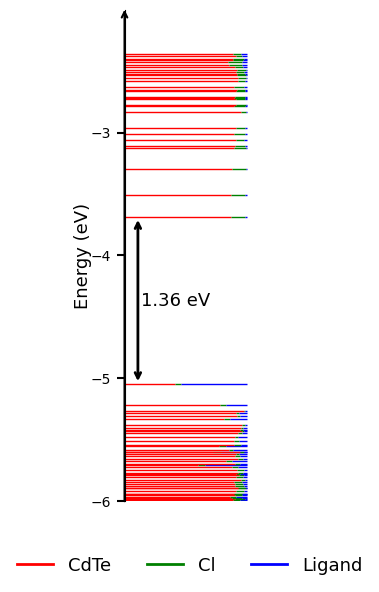

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 读取数据
data = np.loadtxt('./DOS_line.txt')
energy = data[:, 0]
pdos1 = data[:, 2]  # CdTe
pdos2 = data[:, 3]  # Cl
pdos3 = data[:, 4]  # Ligand

fig, ax = plt.subplots(figsize=(3, 6))

# 带隙参数
gap_bottom = -5.046442  # HOMO
gap_top = -3.688221     # LUMO
x_gap = 0.08

# 只绘制-6到-2 eV范围内的能级线
mask = (energy >= -6) & (energy <= -2)
filtered_energy = energy[mask]
filtered_pdos1 = pdos1[mask]
filtered_pdos2 = pdos2[mask]
filtered_pdos3 = pdos3[mask]

# 绘制能级线
scale = 20
for i in range(len(filtered_energy)):
    # CdTe (红色)
    ax.hlines(filtered_energy[i], 0, filtered_pdos1[i]*scale, color='red', linewidth=1)
    # Cl (绿色)
    ax.hlines(filtered_energy[i], filtered_pdos1[i]*scale, (filtered_pdos1[i]+filtered_pdos2[i])*scale, color='green', linewidth=1)
    # Ligand (蓝色)
    ax.hlines(filtered_energy[i], (filtered_pdos1[i]+filtered_pdos2[i])*scale, (filtered_pdos1[i]+filtered_pdos2[i]+filtered_pdos3[i])*scale, color='blue', linewidth=1)

# 带隙箭头
ax.annotate(
    '', xy=(x_gap, gap_top), xytext=(x_gap, gap_bottom),
    arrowprops=dict(arrowstyle='<->', linewidth=2, color='black')
)

# 带隙文字
ax.text(x_gap+0.02, (gap_top+gap_bottom)/2, '1.36 eV', va='center', ha='left', color='black', fontsize=13)

# 设置坐标轴
ax.set_ylim(-6, -2)  # 改为-2作为上界
ax.set_xlim(0, x_gap+0.7)

# Y轴设置
ax.set_ylabel('Energy (eV)', fontsize=13)
ax.yaxis.set_label_coords(-0.25, 0.5)  # 进一步增加x坐标，让标签离y轴更远
# 设置y刻度，只显示-6, -5, -4, -3
yticks = [-6, -5, -4, -3]
ax.set_yticks(yticks)
ax.tick_params(axis='y', length=6, width=1.5)

# X轴设置
ax.set_xticks([])
ax.set_xlabel('')

# 边框设置
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_position(('data', 0))

# 纵坐标箭头 - 确保箭头完整显示
arrowprops = dict(arrowstyle='->', linewidth=1.5, color='black', shrinkA=0, shrinkB=0)
ax.annotate('', xy=(0, -2), xytext=(0, -6), arrowprops=arrowprops)

# 图例
custom_lines = [
    Line2D([0], [0], color='red', lw=2),
    Line2D([0], [0], color='green', lw=2),
    Line2D([0], [0], color='blue', lw=2)
]
ax.legend(custom_lines, ['CdTe', 'Cl', 'Ligand'], 
          loc='upper center', bbox_to_anchor=(0.5, -0.08), 
          ncol=3, frameon=False, fontsize=13)

plt.tight_layout()
plt.show()
